In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp

from myutils_2233 import Ntime, ACFs, set_detectors
from myutils_2233 import ln_likelihood_full_jit

from scipy.linalg import toeplitz
import scipy.signal as sig

import lal
from gwpy.timeseries import TimeSeries
from other_utils import bandpass_ds, analysis_data, interp1d_jax, load_tables

jax.config.update("jax_enable_x64", True) 

/Users/kallol/Work/skyRing/examples/fixed-sky/../../src/myutils_2233.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from corner import corner
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist

import h5py

# Make sure numpyro uses 64-bit too (since you enabled x64 in JAX)
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
tgps = 1242442967.445 + 0.006 
seglen = 8 
fs = 16384 
fmin = 8 
event_id = "GW190521" 
plot_checks = 0 
T = 0.2 
srate = 4096 

ra = 3.5 
dec = 0.73 


factor = 10
seed       = 31567
t0         = 0.0
fmax       = 1500

qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l3/n1l3m3.dat"

tM_shifted_samples_save_dir = "../posterior_files/fixed-sky/GW190521-t-shift-posteriors/"
tM_shifted_220_samples_save_dir = "../posterior_files/fixed-sky/GW190521-220-t-shift-posteriors/"

In [4]:
dH1 = TimeSeries.fetch_open_data('H1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)
dL1 = TimeSeries.fetch_open_data('L1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)

n_analyze = Ntime(srate, T)

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('H1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].location, ra, dec, tgps))
tH1 = tgps + dt_ifo

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('L1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].location, ra, dec, tgps))
tL1 = tgps + dt_ifo

In [5]:
tH1, tL1

(1242442967.4318974, 1242442967.4302728)

In [6]:
# dH1_cond = bandpass_ds(dH1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)
# dL1_cond = bandpass_ds(dL1, t0=tL1, ds=int(fs/srate), trim=0.25, f_min=fmin)

In [7]:
psdH = sig.welch(
    dH1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",   
)

psdL = sig.welch(
    dL1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",  
)

In [8]:
dt_np = 1.0 / srate
Nt     = Ntime(srate=srate, T=T)
freqs_np = onp.fft.rfftfreq(Nt, d=dt_np)

fmin_eff = freqs_np[0]  if (fmin is None) else float(fmin)
fmax_eff = freqs_np[-1] if (fmax is None) else float(fmax)

i0 = int(onp.searchsorted(freqs_np, fmin_eff, side="left"))
i1 = int(onp.searchsorted(freqs_np, fmax_eff, side="right"))

freqs = jnp.asarray(freqs_np, dtype=jnp.float64)

# Prior limits
limits = [
    [30.0, 500.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0., 3.141592653589793]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

In [9]:
psdH = interp1d_jax(jnp.asarray(psdH[0],dtype=jnp.float64), jnp.asarray(psdH[1],dtype=jnp.float64))
psdL = interp1d_jax(jnp.asarray(psdL[0],dtype=jnp.float64), jnp.asarray(psdL[1],dtype=jnp.float64))

omega_22_r, omega_22_i, omega_33_r, omega_33_i = load_tables(qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

rhoH, rhoL = ACFs(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
covH=toeplitz(rhoH)
covL=toeplitz(rhoL)
L_H=jnp.linalg.cholesky(covH)
L_L=jnp.linalg.cholesky(covL)

resp_H_py = lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].response
resp_L_py = lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].response
resp_H = jnp.asarray(resp_H_py, dtype=jnp.float64)
resp_L = jnp.asarray(resp_L_py, dtype=jnp.float64)

set_detectors(resp_H, resp_L)

In [10]:
MTSUN = lal.MTSUN_SI
tM = MTSUN * 325 # Remnant mass peak

In [11]:
num_shifts = 15

t_shifts = []
H1_data_t_shifted = []
L1_data_t_shifted = []

for jj in range(num_shifts):

    dH1_cond = bandpass_ds(dH1, t0=tH1 + (-3 + jj)*1*tM, ds=int(fs/srate), trim=0.25, f_min=fmin)
    dL1_cond = bandpass_ds(dL1, t0=tL1 + (-3 + jj)*1*tM, ds=int(fs/srate), trim=0.25, f_min=fmin)

    dH1_analysis_data = analysis_data(dH1_cond[1], dH1_cond[0], tH1 + (-3 + jj)*1*tM, n_analyze)
    dL1_analysis_data = analysis_data(dL1_cond[1], dL1_cond[0], tL1 + (-3 + jj)*1*tM, n_analyze)

    t_shifts.append((-3 + jj)*1*tM)
    H1_data_t_shifted.append(dH1_analysis_data[1])
    L1_data_t_shifted.append(dL1_analysis_data[1])

In [12]:
onp.savetxt(tM_shifted_samples_save_dir + 't_shifts.txt', t_shifts)

In [13]:
low  = jnp.asarray(low,  dtype=jnp.float64)
high = jnp.asarray(high, dtype=jnp.float64)

theta_fixed_sky = jnp.array([ra, dec]) 

In [14]:

# for i in range(12,num_shifts):
    # print(i, t_shifts[i])

In [15]:
logZs = []

for i in range(12, num_shifts):
    h_H_t = H1_data_t_shifted[i]
    h_L_t = L1_data_t_shifted[i]

    def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                    omega_22_r, omega_22_i, omega_33_r, omega_33_i,
                    T, srate, t0):
        def _loglik(theta):
            return ln_likelihood_full_jit(
                dataH=dataH, dataL=dataL, params=theta,
                gmst=gmst, L_H=L_H, L_L=L_L,
                omega_22_r=omega_22_r, omega_22_i=omega_22_i,
                omega_33_r=omega_33_r, omega_33_i=omega_33_i,
                T=T, srate=srate, t0=t0
            )
        return _loglik

    loglik_fn = make_loglik_fn(
        dataH=h_H_t, dataL=h_L_t,
        gmst=gmst, L_H=L_H, L_L=L_L,
        omega_22_r=omega_22_r, omega_22_i=omega_22_i,
        omega_33_r=omega_33_r, omega_33_i=omega_33_i,
        T=T, srate=srate, t0=t0
    )

    def model_fixed_sky():
        theta_free = numpyro.sample("theta", dist.Uniform(low, high)) 
        theta = jnp.concatenate([theta_free[:-1], theta_fixed_sky, jnp.array([theta_free[-1]])], axis=0)
        numpyro.factor("loglike", loglik_fn(theta))

    rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
    rng_run, rng_post = jax.random.split(rng_key)
    ns_fixed_sky = NestedSampler(
        model_fixed_sky,
        constructor_kwargs=dict(
            num_live_points=10000,    
            max_samples=500_000,      
            verbose=True,
        ),
        termination_kwargs=dict(
            dlogZ=0.01,            
        ),
    )
    ns_fixed_sky.run(rng_run)
    ns_fixed_sky.print_summary()
    posterior_fixed_sky = ns_fixed_sky.get_samples(rng_post, num_samples=100_000)

    onp.save(tM_shifted_samples_save_dir + 'posterior.' + event_id + '.' + str(i) + '.npy', onp.asarray(posterior_fixed_sky['theta']))
    logZs.append(ns_fixed_sky._results.log_Z_mean)
    # onp.savetxt(tM_shifted_samples_save_dir + 'logZs.txt', onp.asarray(logZs))


INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 267744
Efficiency: 0.03602501016893023
log(L) contour: -5175.603634344581
log(Z) est.: -828.338287040709 +- 0.5329336702056781
log(Z | remaining) est.: 4357.530589443635 +- 0.8706418403078886
ESS: 1.5220366977170303

-------
Num samples: 10008
Num likelihood evals: 565014
Efficiency: 0.023063999834071945
log(L) contour: -2237.829695491313
log(Z) est.: -828.3507967642935 +- 0.41512912943981445
log(Z | remaining) est.: 1418.7013995862112 +- 0.5295883922470533
ESS: 2.6585500308433923

-

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 267131
Efficiency: 0.036101161167444024
log(L) contour: -5176.86928631276
log(Z) est.: -834.9941915872469 +- 0.4854081176992686
log(Z | remaining) est.: 4352.5742729668855 +- 0.9525905400843145
ESS: 1.8815062978984483

-------
Num samples: 10008
Num likelihood evals: 564634
Efficiency: 0.023074901203085876
log(L) contour: -2240.272729239223
log(Z) est.: -832.7843584265449 +- 0.639951538103237
log(Z | remaining) est.: 1416.3311660618945 +- 0.7154830338370934
ESS: 0.9879045753609884

-

INFO:jaxns:Number of Markov-chains set to: 10000


--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 21148457
samples: 175140
phantom samples: 0
likelihood evals / sample: 120.8
phantom fraction (%): 0.0%
--------
logZ=-830.038 +- 0.04
max(logL)=-814.328
H=-11.13
ESS=23161
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 264.0 +- 48.0 | 211.0 / 254.0 / 331.0 | 324.0 | 324.0
theta[1]: 0.46 +- 0.25 | 0.1 / 0.46 / 0.8 | 0.85 | 0.85
theta[2]: 0.36 +- 0.27 | 0.14 / 0.26 / 0.7 | 0.6 | 0.6
theta[3]: 3.3 +- 1.8 | 0.8 / 3.0 / 5.7 | 4.0 | 4.0
theta[4]: 0.09 +- 0.11 | 0.01 / 0.06 / 0.19 | 0.08 | 0.08
theta[5]: 3.1 +- 1.8 | 0.6 / 3.1 / 5.7 | 6.2 | 6.2
theta[6]: -0.15 +- 0.32 | -0.55 / -0.14 / 0.2 | -0.12 | -0.12
theta[7]: 1.61 +- 0.9 | 0.42 / 1.76 / 2.81 | 0.6 | 0.6
--------
Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(e

In [15]:
logZs

[Array(-827.6787956, dtype=float64),
 Array(-820.98696555, dtype=float64),
 Array(-824.69654881, dtype=float64),
 Array(-825.11326304, dtype=float64),
 Array(-826.05801443, dtype=float64),
 Array(-822.07767897, dtype=float64),
 Array(-822.18564732, dtype=float64),
 Array(-819.56132726, dtype=float64),
 Array(-821.98901628, dtype=float64),
 Array(-825.54000989, dtype=float64),
 Array(-824.99494054, dtype=float64),
 Array(-822.05016536, dtype=float64),
 Array(-822.14297871, dtype=float64),
 Array(-827.24012653, dtype=float64),
 Array(-824.01060125, dtype=float64)]

In [15]:
logZs


[Array(-824.69654881, dtype=float64),
 Array(-825.11326304, dtype=float64),
 Array(-826.05801443, dtype=float64),
 Array(-822.07767897, dtype=float64),
 Array(-822.18564732, dtype=float64),
 Array(-819.56132726, dtype=float64),
 Array(-821.98901628, dtype=float64),
 Array(-825.54000989, dtype=float64),
 Array(-824.99494054, dtype=float64),
 Array(-822.05016536, dtype=float64),
 Array(-822.14297871, dtype=float64),
 Array(-827.24012653, dtype=float64)]

In [16]:
logZs

[Array(-824.01060125, dtype=float64),
 Array(-830.03844259, dtype=float64),
 Array(-822.53992978, dtype=float64)]

In [17]:
limits = [
    [30.0, 500.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0., 3.141592653589793]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

In [18]:
logZs_220 = []

for i in range(12,num_shifts):
    h_H_t = H1_data_t_shifted[i]
    h_L_t = L1_data_t_shifted[i]

    def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                    omega_22_r, omega_22_i, omega_33_r, omega_33_i,
                    T, srate, t0):
        def _loglik(theta):
            return ln_likelihood_full_jit(
                dataH=dataH, dataL=dataL, params=theta,
                gmst=gmst, L_H=L_H, L_L=L_L,
                omega_22_r=omega_22_r, omega_22_i=omega_22_i,
                omega_33_r=omega_33_r, omega_33_i=omega_33_i,
                T=T, srate=srate, t0=t0
            )
        return _loglik

    loglik_fn = make_loglik_fn(
        dataH=h_H_t, dataL=h_L_t,
        gmst=gmst, L_H=L_H, L_L=L_L,
        omega_22_r=omega_22_r, omega_22_i=omega_22_i,
        omega_33_r=omega_33_r, omega_33_i=omega_33_i,
        T=T, srate=srate, t0=t0
    )

    def model_fixed_sky_220():
        theta_free = numpyro.sample("theta", dist.Uniform(low, high))
        amp_phase_330 = jnp.array([0., 0.])
        theta = jnp.concatenate([theta_free[:4], amp_phase_330, theta_free[4:5], theta_fixed_sky, jnp.array([theta_free[-1]])], axis=0)
        numpyro.factor("loglike", loglik_fn(theta))

    rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
    rng_run, rng_post = jax.random.split(rng_key)
    ns_fixed_sky = NestedSampler(
        model_fixed_sky_220,
        constructor_kwargs=dict(
            num_live_points=10000,    
            max_samples=500_000,      
            verbose=True,
        ),
        termination_kwargs=dict(
            dlogZ=0.01,            
        ),
    )
    ns_fixed_sky.run(rng_run)
    ns_fixed_sky.print_summary()
    posterior_fixed_sky = ns_fixed_sky.get_samples(rng_post, num_samples=100_000)

    onp.save(tM_shifted_220_samples_save_dir + 'posterior.' + event_id + '.' + str(i) + '.npy', onp.asarray(posterior_fixed_sky['theta']))
    logZs_220.append(ns_fixed_sky._results.log_Z_mean)
    # onp.savetxt(tM_shifted_220_samples_save_dir + 'logZs_220.txt', onp.asarray(logZs_220))


INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 182511
Efficiency: 0.05337173026157908
log(L) contour: -2397.313604598029
log(Z) est.: -822.2295483472705 +- 0.35838209270318566
log(Z | remaining) est.: 1584.468200139098 +- 0.6480605831642563
ESS: 3.6469580538535302

-------
Num samples: 10008
Num likelihood evals: 392142
Efficiency: 0.033278357097254734
log(L) contour: -1138.2957955552204
log(Z) est.: -821.6406023924006 +- 0.24643037155649372
log(Z | remaining) est.: 324.6121696376216 +- 0.33828633509701955
ESS: 7.985973626613171


INFO:jaxns:Number of Markov-chains set to: 10000


--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 15539506
samples: 140112
phantom samples: 0
likelihood evals / sample: 110.9
phantom fraction (%): 0.0%
--------
logZ=-821.223 +- 0.034
max(logL)=-810.116
H=-8.13
ESS=19815
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 264.0 +- 40.0 | 214.0 / 261.0 / 317.0 | 300.0 | 300.0
theta[1]: 0.54 +- 0.23 | 0.18 / 0.58 / 0.82 | 0.79 | 0.79
theta[2]: 0.28 +- 0.21 | 0.12 / 0.21 / 0.51 | 0.62 | 0.62
theta[3]: 3.2 +- 1.8 | 0.8 / 3.2 / 5.5 | 0.0 | 0.0
theta[4]: -0.2 +- 0.45 | -0.77 / -0.23 / 0.46 | -0.14 | -0.14
theta[5]: 1.52 +- 0.88 | 0.36 / 1.55 / 2.74 | 2.12 | 2.12
--------
Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=Tr

INFO:jaxns:Number of Markov-chains set to: 10000


--------
Termination Conditions:
Small remaining evidence
--------
likelihood evals: 15968549
samples: 140112
phantom samples: 0
likelihood evals / sample: 114.0
phantom fraction (%): 0.0%
--------
logZ=-827.198 +- 0.035
max(logL)=-816.293
H=-8.24
ESS=19222
--------
theta[#]: mean +- std.dev. | 10%ile / 50%ile / 90%ile | MAP est. | max(L) est.
theta[0]: 247.0 +- 37.0 | 206.0 / 240.0 / 298.0 | 267.0 | 267.0
theta[1]: 0.43 +- 0.24 | 0.1 / 0.43 / 0.76 | 0.63 | 0.63
theta[2]: 0.3 +- 0.22 | 0.13 / 0.23 / 0.56 | 0.7 | 0.7
theta[3]: 3.3 +- 1.8 | 0.7 / 3.2 / 5.7 | 3.9 | 3.9
theta[4]: -0.23 +- 0.43 | -0.78 / -0.25 / 0.39 | -0.15 | -0.15
theta[5]: 1.5 +- 0.89 | 0.32 / 1.54 / 2.72 | 0.57 | 0.57
--------
Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True),

INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode


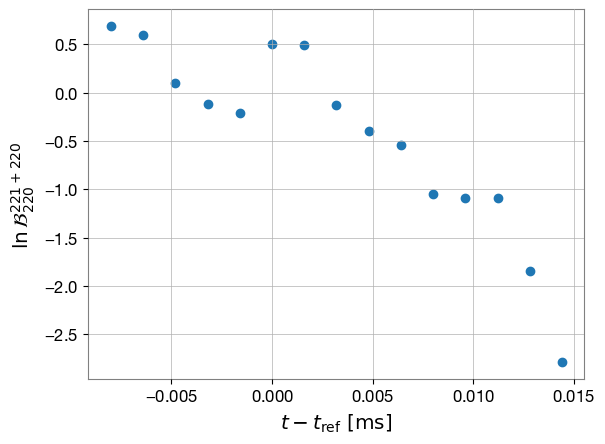

In [19]:
plt.scatter(t_shifts, onp.array(logZs) - onp.array(logZs_220))
plt.xlabel(r'$t - t_{\mathrm{ref}}\ \mathrm{[ms]}$')
plt.ylabel(r'$\ln \mathcal{B}^{221+220}_{220}$')
plt.show()

INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol B from STIXNonUnicode


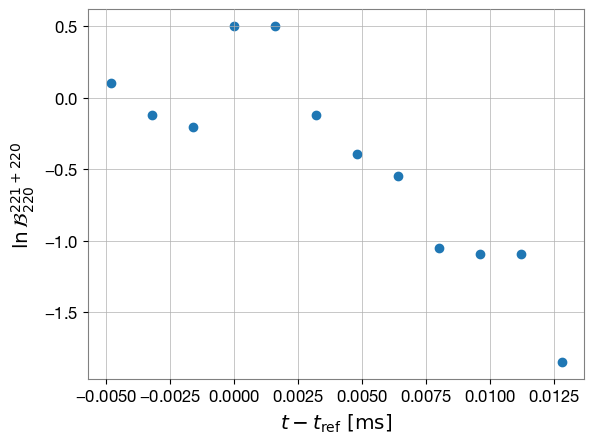

In [18]:
plt.scatter(t_shifts, onp.array(logZs) - onp.array(logZs_220))
plt.xlabel(r'$t - t_{\mathrm{ref}}\ \mathrm{[ms]}$')
plt.ylabel(r'$\ln \mathcal{B}^{221+220}_{220}$')
plt.show()